# 데이터 탐색

**목적**: Olist 브라질 이커머스 데이터셋의 구조·분포를 파악하고,  
고객 이탈 예측 모델의 방향성을 설정하기 위한 분석

**Time-based Split 기준**
- 피처 추출 구간: 2016-09 ~ 2018-03

---
## 0. 라이브러리 & 설정

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_theme(font_scale=2.5)

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

---
## 1. 데이터 로드 & 날짜 파싱

In [46]:
orders = pd.read_csv('../data/raw/orders.csv')
customers = pd.read_csv('../data/raw/customers.csv')

dt_col = ['order_purchase_timestamp',
          'order_delivered_carrier_date',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']

for col in dt_col:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

---
## 2. delivered 필터링 & 조인

In [47]:
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# customer_id로 조인 → customer_unique_id 확보
df = orders_delivered.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id", how="left"
)

---
## 3. 주문 단위 파생 피처

In [48]:
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['actual_delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

df['is_delayed'] = df['delivery_delay_days'] > 0

---
## 4. 고객 단위 집계

In [49]:
# Time-based split 기준
FEAT_START  = pd.Timestamp("2016-09-01")
FEAT_END    = pd.Timestamp("2018-03-31")
LABEL_START = pd.Timestamp("2018-04-01")
LABEL_END   = pd.Timestamp("2018-10-31")

# 피처 추출 구간 필터링 (leakage 방지)
feat_df = df[
    (df["order_purchase_timestamp"] >= FEAT_START) &
    (df["order_purchase_timestamp"] <= FEAT_END)
].copy()

# 이탈 레이블: 레이블 구간에 재구매한 고객 집합
label_orders = df[
    (df["order_purchase_timestamp"] >= LABEL_START) &
    (df["order_purchase_timestamp"] <= LABEL_END)
]
retained = set(label_orders["customer_unique_id"].dropna())

# 마지막 주문이 지연된 고객 (customer_unique_id 기준)
df_sorted = feat_df.sort_values("order_purchase_timestamp")
last_order_delayed = (
    df_sorted.groupby("customer_unique_id")["is_delayed"]
    .last()
    .reset_index()
    .rename(columns={"is_delayed": "last_order_delayed"})
)

customer_df = feat_df.groupby("customer_unique_id").agg(
    total_orders=("order_id", "count"),
    max_delay_days=("delivery_delay_days", "max"),
    mean_delay_days=("delivery_delay_days", "mean"),
    delay_count=("is_delayed", "sum"),
    mean_actual_delivery_days=("actual_delivery_days", "mean"),
).reset_index()

customer_df["delay_rate"] = customer_df["delay_count"] / customer_df["total_orders"]
customer_df = customer_df.merge(last_order_delayed, on="customer_unique_id", how="left")

# 이탈 레이블 부여
customer_df["churn"] = customer_df["customer_unique_id"].apply(
    lambda x: 0 if x in retained else 1
)

print(f"피처 구간 주문 수: {len(feat_df):,}")
print(f"피처 구간 고객 수: {len(customer_df):,}")
print(f"이탈 고객: {customer_df['churn'].sum():,} ({customer_df['churn'].mean():.1%})")
print(f"잔존 고객: {(customer_df['churn']==0).sum():,}")

피처 구간 주문 수: 64,158
피처 구간 고객 수: 62,145
이탈 고객: 61,544 (99.0%)
잔존 고객: 601


---
## 5. 결측치 현황

In [50]:
order_feat_cols = ["delivery_delay_days", "actual_delivery_days", "is_delayed"]
customer_feat_cols = [
    "total_orders", "max_delay_days", "mean_delay_days",
    "delay_count", "delay_rate", "mean_actual_delivery_days", "last_order_delayed", "churn"
]

print("=" * 60)
print("[주문 단위 피처] 결측치")
print("=" * 60)
order_null = feat_df[order_feat_cols].isnull().sum().to_frame("결측치 수")
order_null["비율(%)"] = (order_null["결측치 수"] / len(feat_df) * 100).round(2)
print(order_null)
print(f"\n전체 주문 수: {len(feat_df):,}")

print("\n" + "=" * 60)
print("[고객 단위 피처] 결측치")
print("=" * 60)
customer_null = customer_df[customer_feat_cols].isnull().sum().to_frame("결측치 수")
customer_null["비율(%)"] = (customer_null["결측치 수"] / len(customer_df) * 100).round(2)
print(customer_null)
print(f"\n전체 고객 수: {len(customer_df):,}")

[주문 단위 피처] 결측치
                      결측치 수  비율(%)
delivery_delay_days       2    0.0
actual_delivery_days      2    0.0
is_delayed                0    0.0

전체 주문 수: 64,158

[고객 단위 피처] 결측치
                           결측치 수  비율(%)
total_orders                   0    0.0
max_delay_days                 2    0.0
mean_delay_days                2    0.0
delay_count                    0    0.0
delay_rate                     0    0.0
mean_actual_delivery_days      2    0.0
last_order_delayed             0    0.0
churn                          0    0.0

전체 고객 수: 62,145


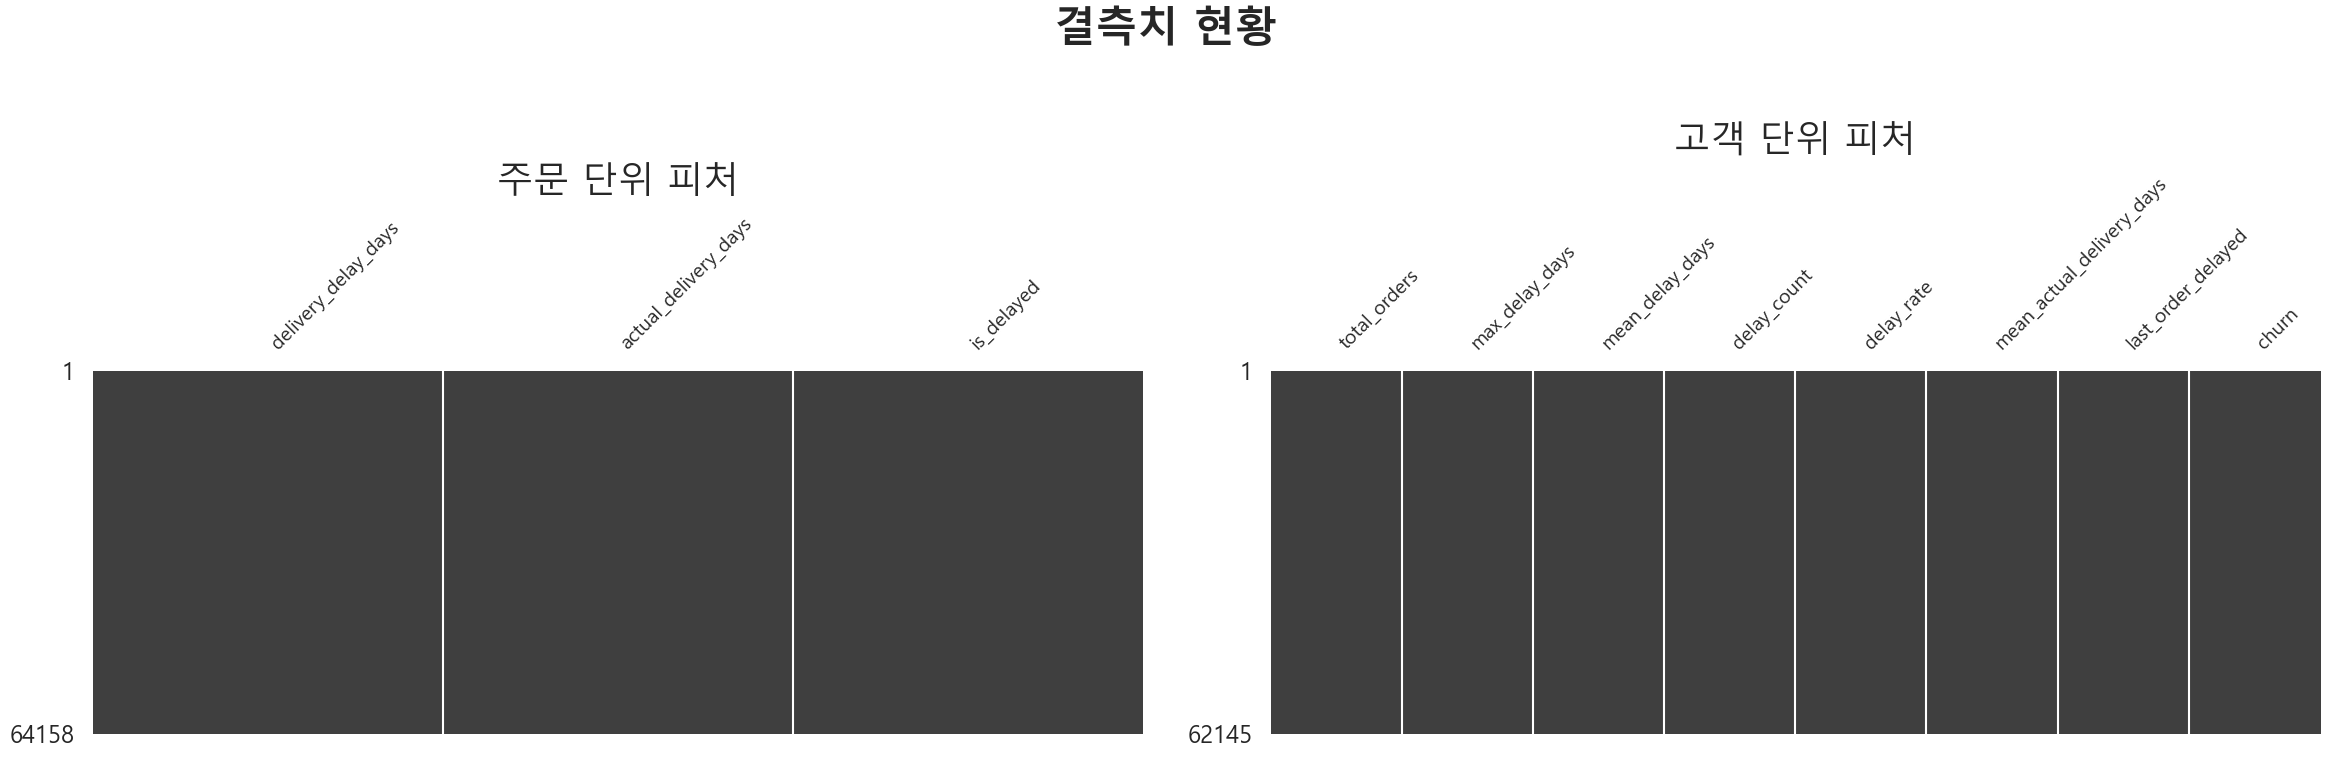

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(24, 8))
fig.suptitle("결측치 현황", fontsize=30, fontweight="bold")

msno.matrix(feat_df[order_feat_cols], ax=axes[0], fontsize=14)
axes[0].set_title("주문 단위 피처", fontsize=26, pad=15)

msno.matrix(customer_df[customer_feat_cols], ax=axes[1], fontsize=14)
axes[1].set_title("고객 단위 피처", fontsize=26, pad=15)

plt.tight_layout()
plt.show()

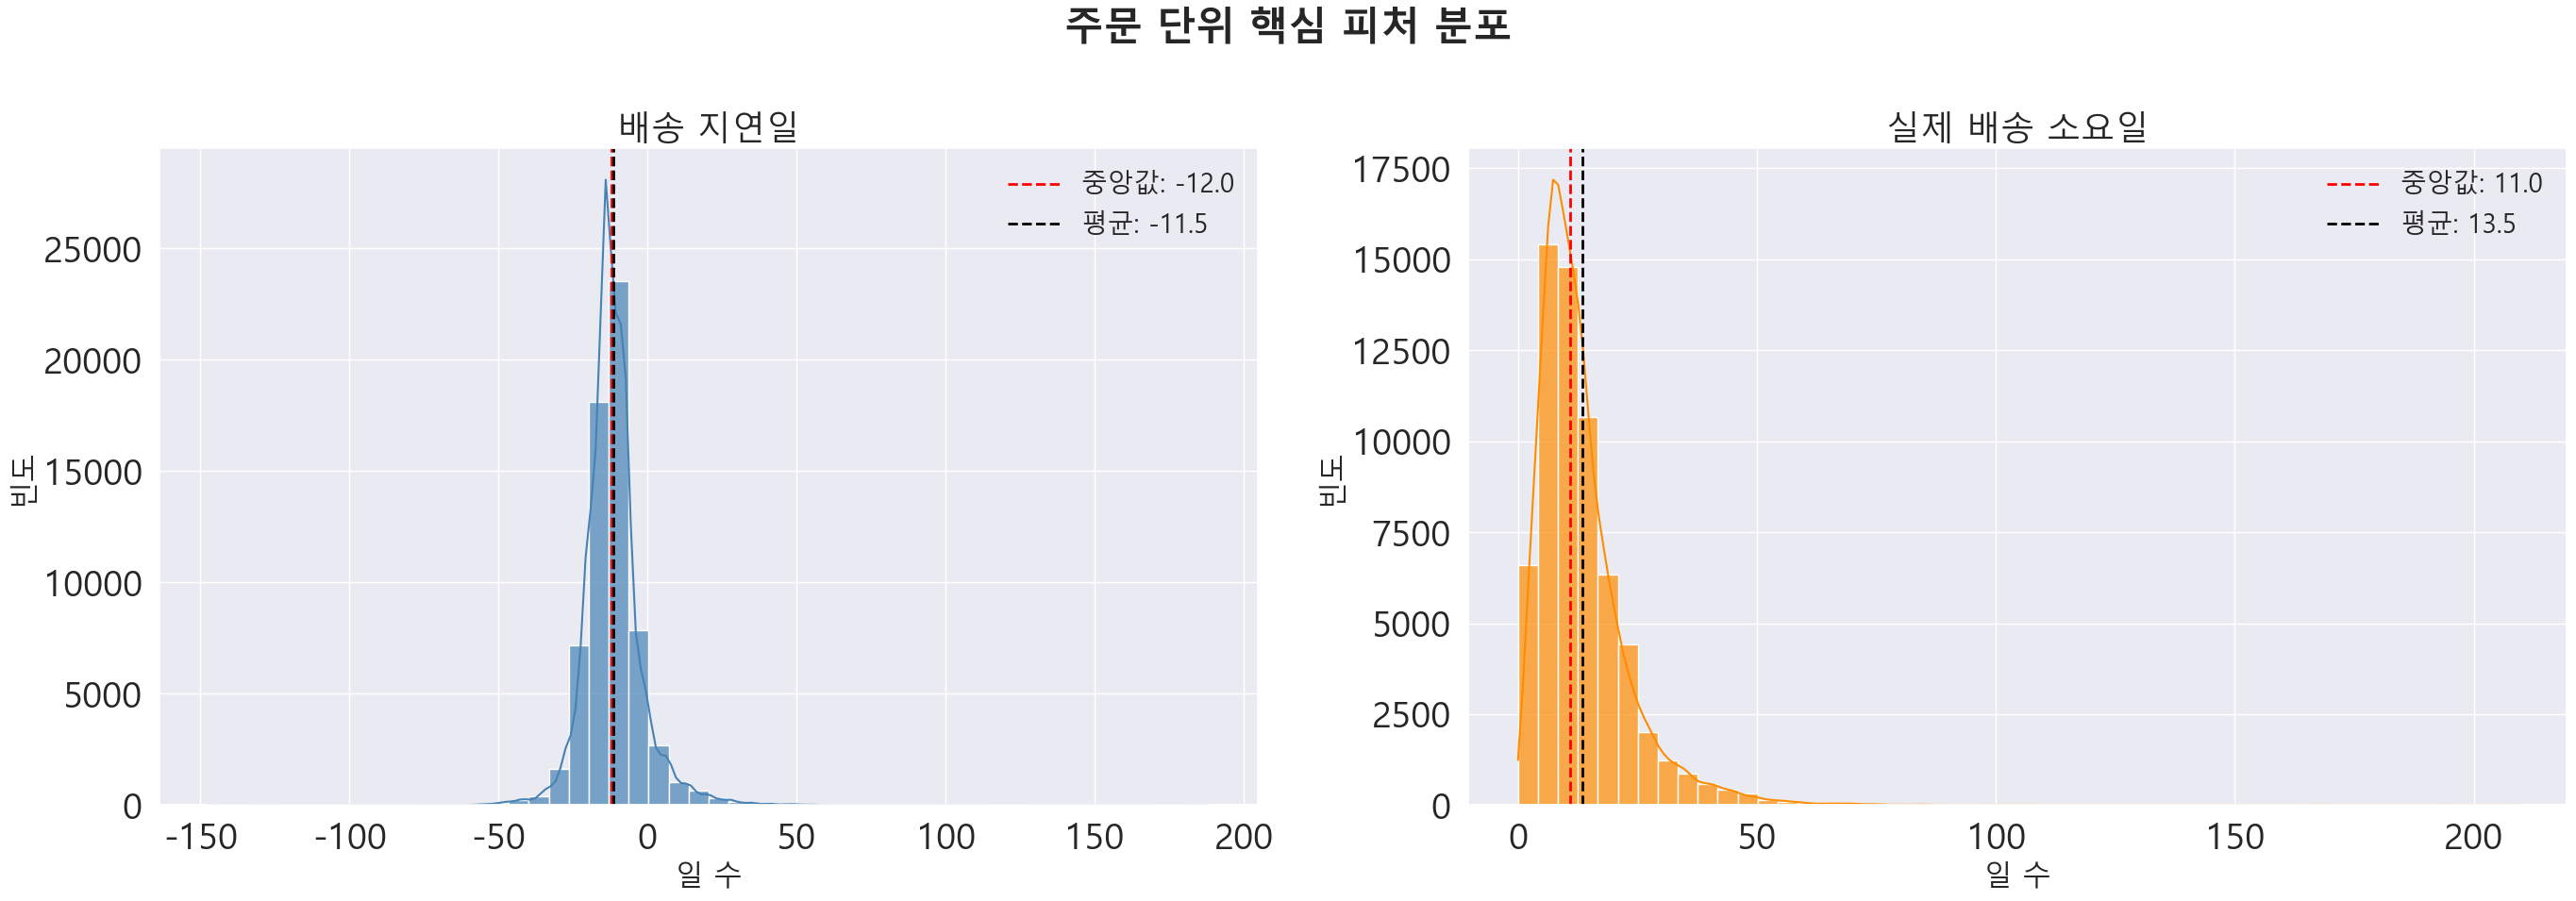

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(28, 10))
fig.suptitle("주문 단위 핵심 피처 분포", fontsize=30, fontweight="bold")

for ax, (col, title, color) in zip(axes, [
    ("delivery_delay_days", "배송 지연일", "steelblue"),
    ("actual_delivery_days", "실제 배송 소요일", "darkorange"),
]):
    data = feat_df[col].dropna()
    sns.histplot(data, ax=ax, color=color, bins=50, kde=True, alpha=0.7)
    ax.axvline(data.median(), color="red", linestyle="--", linewidth=2,
               label=f"중앙값: {data.median():.1f}")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=2,
               label=f"평균: {data.mean():.1f}")
    ax.set_title(title, fontsize=26)
    ax.set_xlabel("일 수", fontsize=22)
    ax.set_ylabel("빈도", fontsize=22)
    ax.legend(fontsize=20)

plt.tight_layout()
plt.show()

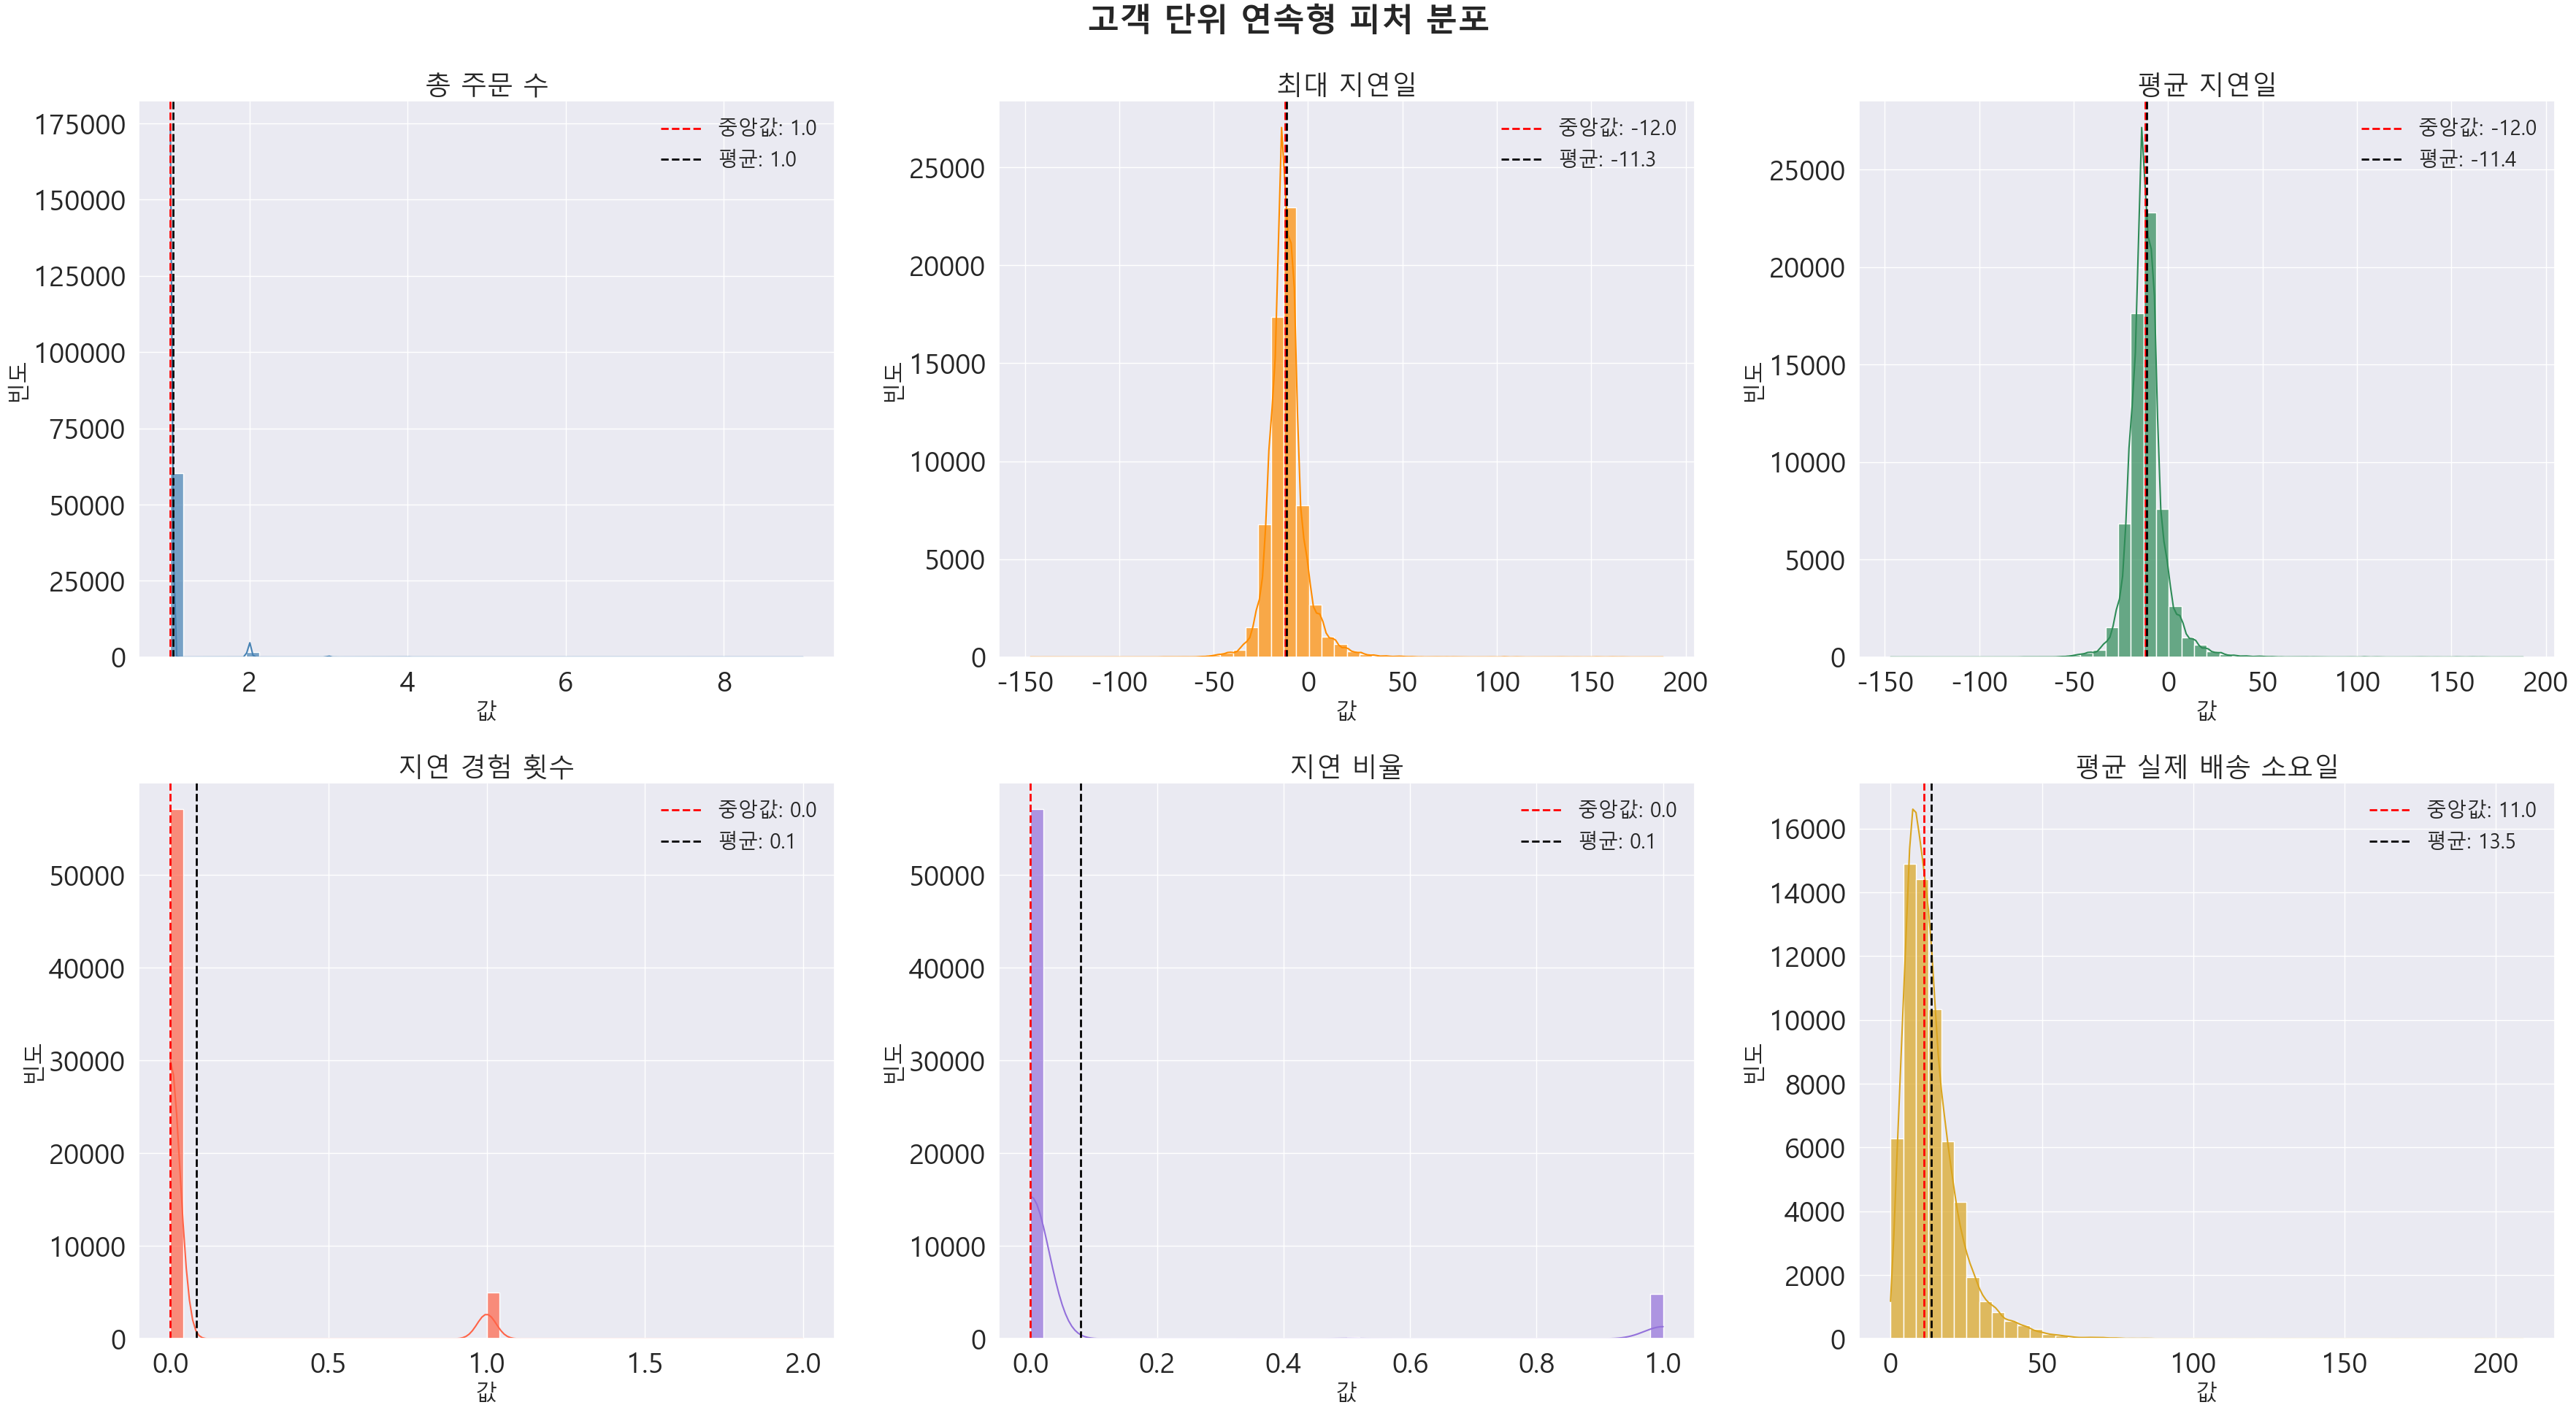

In [53]:
customer_cont_feats = [
    ('total_orders',              '총 주문 수',           'steelblue'),
    ('max_delay_days',            '최대 지연일',          'darkorange'),
    ('mean_delay_days',           '평균 지연일',          'seagreen'),
    ('delay_count',               '지연 경험 횟수',       'tomato'),
    ('delay_rate',                '지연 비율',            'mediumpurple'),
    ('mean_actual_delivery_days', '평균 실제 배송 소요일', 'goldenrod'),
]

fig, axes = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle('고객 단위 연속형 피처 분포', fontsize=32, fontweight='bold')
axes = axes.flatten()

for ax, (col, title, color) in zip(axes, customer_cont_feats):
    data = customer_df[col].dropna()
    sns.histplot(data, ax=ax, color=color, bins=50, kde=True, alpha=0.7)
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=2,
               label=f'중앙값: {data.median():.1f}')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=2,
               label=f'평균: {data.mean():.1f}')
    ax.set_title(title, fontsize=26)
    ax.set_xlabel('값', fontsize=22)
    ax.set_ylabel('빈도', fontsize=22)
    ax.legend(fontsize=20)

plt.tight_layout()
plt.show()

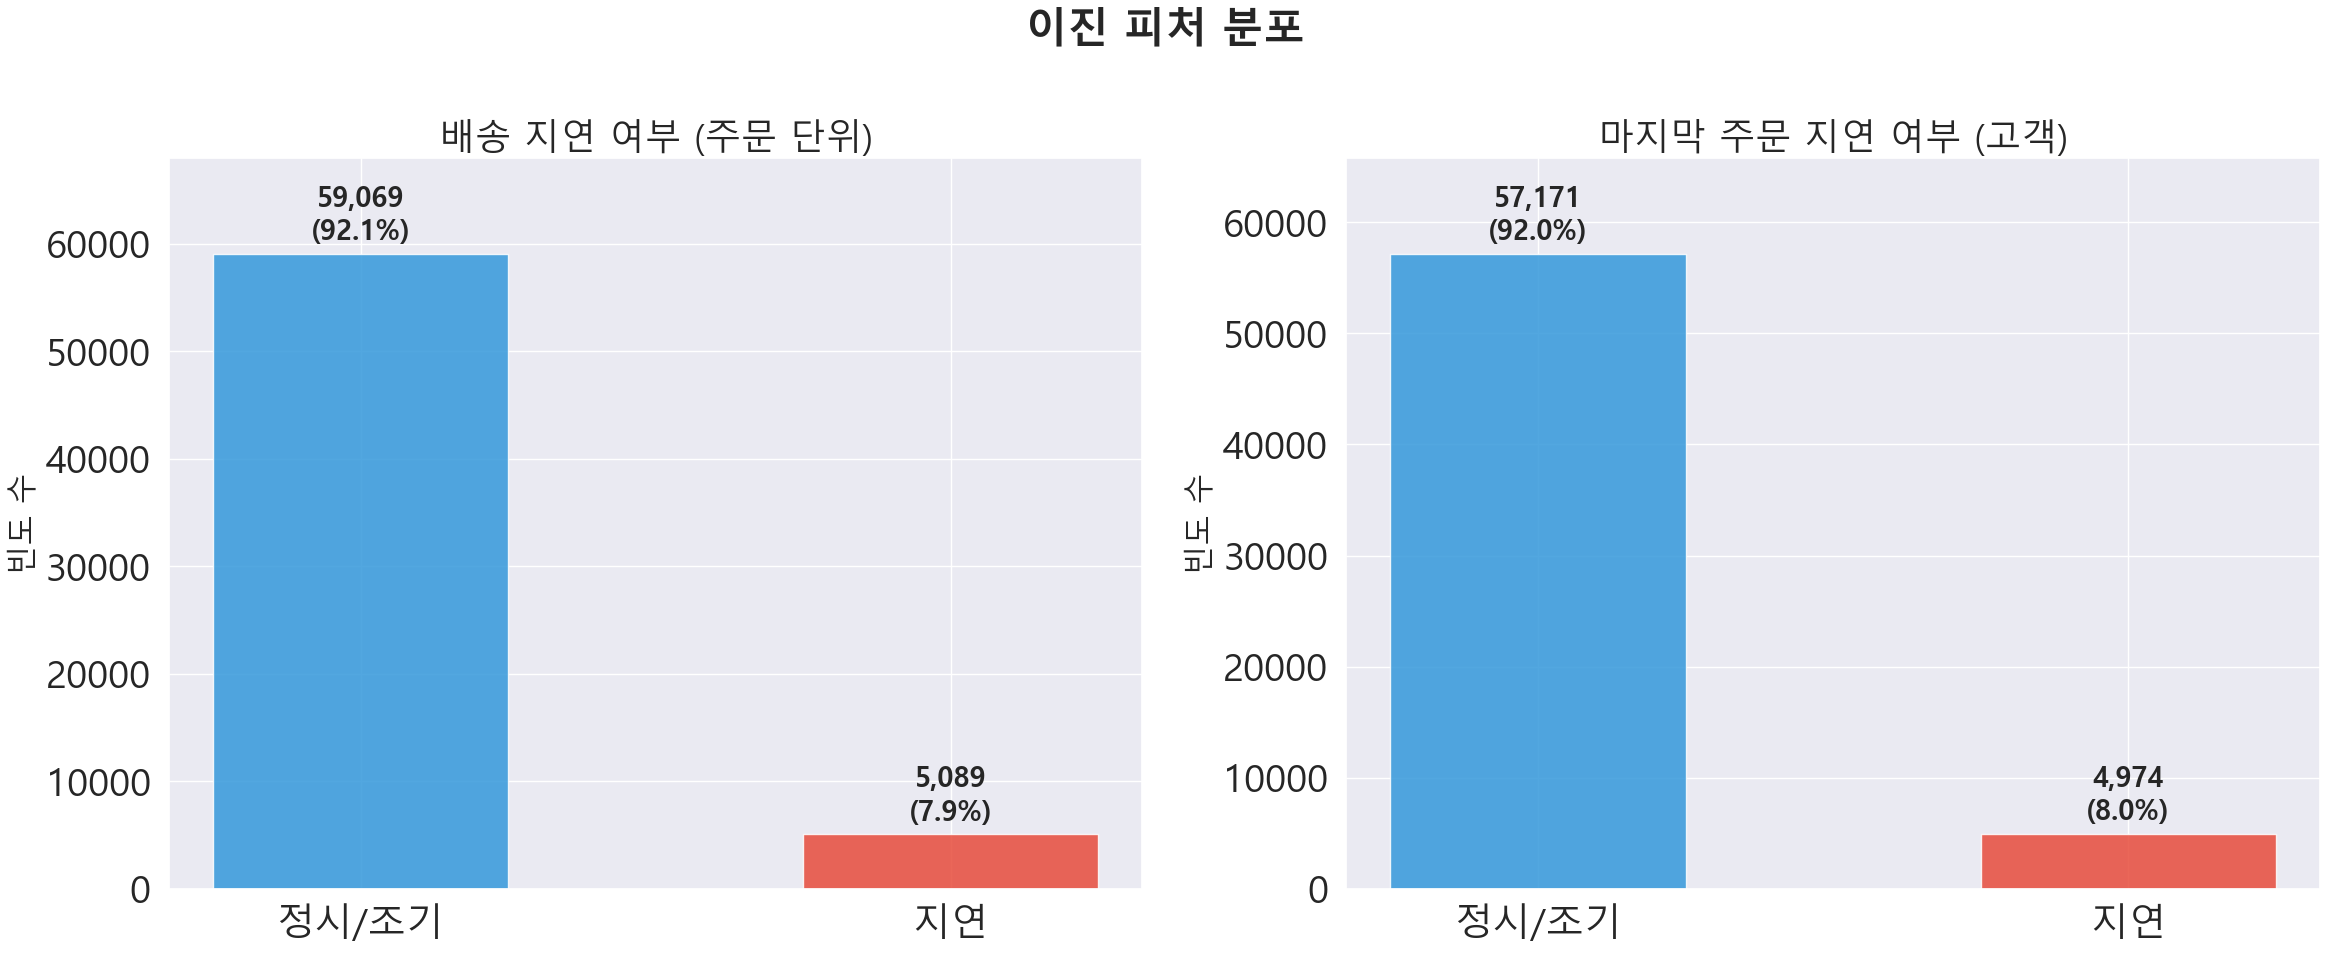

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle("이진 피처 분포", fontsize=30, fontweight="bold")

binary_feats = [
    (feat_df["is_delayed"],             "배송 지연 여부 (주문 단위)",   ["정시/조기", "지연"]),
    (customer_df["last_order_delayed"], "마지막 주문 지연 여부 (고객)", ["정시/조기", "지연"]),
]

colors = ["#3498db", "#e74c3c"]

for ax, (data, title, labels) in zip(axes, binary_feats):
    counts = data.value_counts().sort_index()
    bars = ax.bar(labels, counts.values, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + counts.max() * 0.01,
                f"{val:,}\n({val/len(data)*100:.1f}%)",
                ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax.set_title(title, fontsize=26)
    ax.set_ylabel("빈도 수", fontsize=22)
    ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()